In [53]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## READ DATA
train_data = pd.read_csv(r"D:\DataScience\StoreSales\data\train.csv")
stores_data = pd.read_csv(r"D:\DataScience\StoreSales\data\stores.csv")
holidays_events_data = pd.read_csv(r"D:\DataScience\StoreSales\data\holidays_events.csv")
transactions_data = pd.read_csv(r"D:\DataScience\StoreSales\data\transactions.csv")
oil_data = pd.read_csv(r"D:\DataScience\StoreSales\data\oil.csv")


data_contain_date = [train_data, holidays_events_data, transactions_data, oil_data]
for data in data_contain_date:
    data["date"] = pd.to_datetime(data["date"])
    

KIỂM TRA DỮ LIỆU

In [55]:
train_data.info()
train_data.isnull().sum()

holidays_events_data.isna().sum()
transactions_data.isna().sum()

"""check thấy có 43 giá trị nan, vì giá trị xăng
dao động so với các ngày trước là không quá nhiều nên quyết định chọn
fill bằng cách lấy giá xăng ngày trước"""
oil_data["dcoilwtico"] = oil_data["dcoilwtico"].ffill()
oil_data.isnull().sum()
oil_data.to_csv("data\oil.csv", index = False)

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 168.2 MB


PHÂN TÍCH TARGET (SALES)

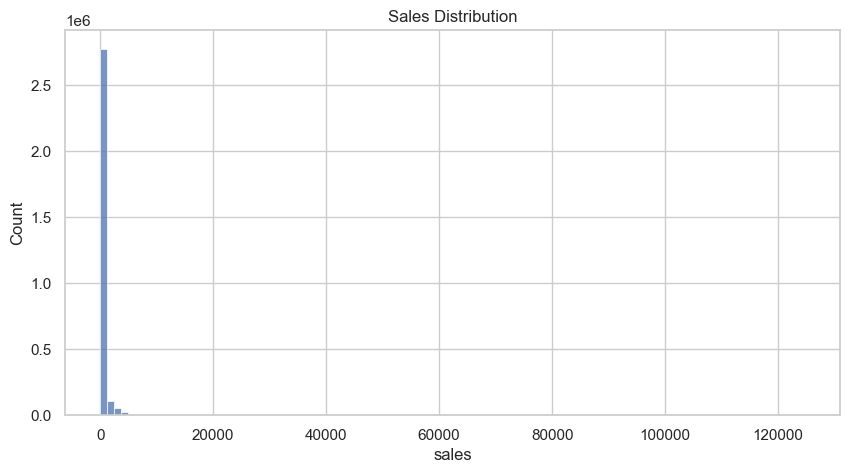

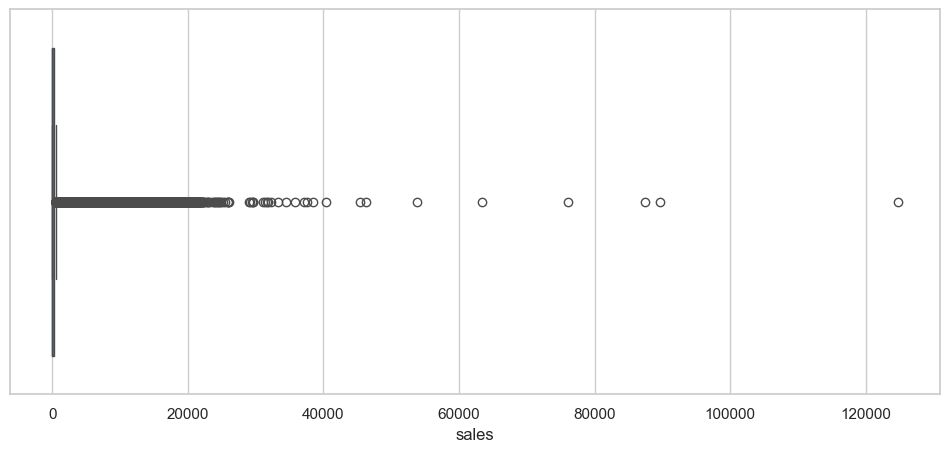

In [56]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(train_data["sales"], bins=100)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x=train_data["sales"])
plt.show()

PHÂN TÍCH DOANH THU THEO THỜI GIAN

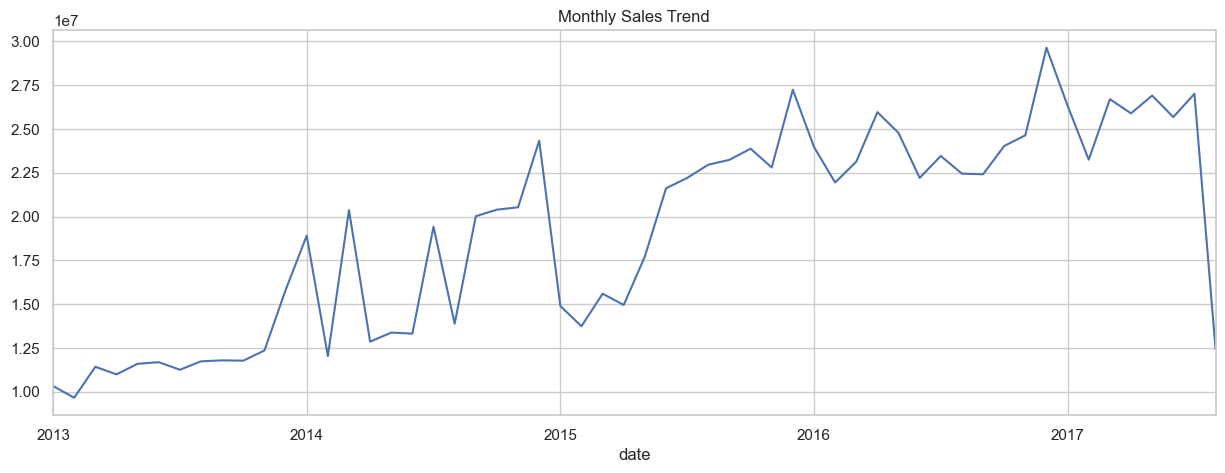

In [57]:
monthly_sales = (
    train_data.groupby(pd.Grouper(key="date",freq="ME"))["sales"]
    .sum()
)

monthly_sales.plot(figsize=(15,5))
plt.title("Monthly Sales Trend")
plt.show()

TỔNG DOANH THU THEO FAMILY

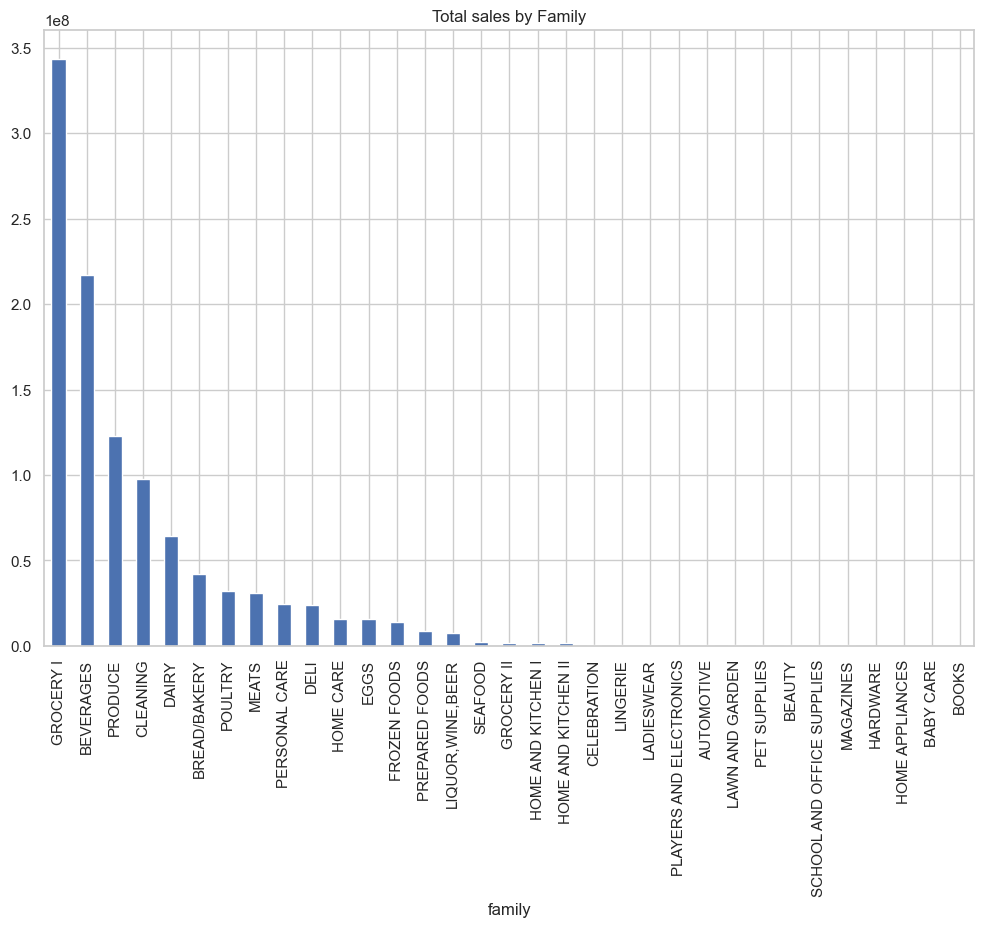

In [58]:
family_sales = train_data.groupby("family")["sales"].sum().sort_values(ascending= False)
plt.figure(figsize = (12,8))
family_sales.plot(kind = "bar")
plt.title("Total sales by Family")
plt.show()

SALES THEO FAMILY QUA THỜI GIAN

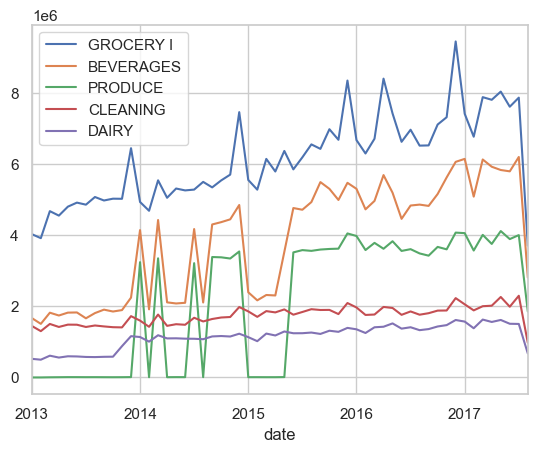

In [59]:
top5 = family_sales.head(5).index

for fam in top5:
    temp = train_data[train_data["family"]==fam]

    monthly = (
        temp.groupby(pd.Grouper(key="date",freq="ME"))
        ["sales"]
        .sum()
    )

    monthly.plot(label=fam)

plt.legend()
plt.show()

SALES THEO THÁNG

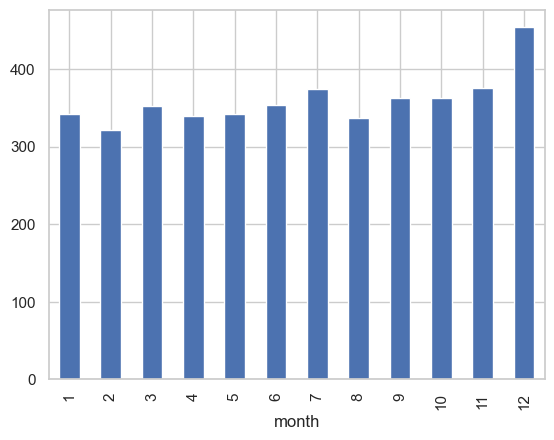

In [60]:
month_sales = train_data.groupby(train_data["date"].dt.month)["sales"].mean()

month_sales.plot(kind = "bar")
plt.xlabel("month")
plt.show()


PHÂN TÍCH TRANSACTIONS CÓ TƯƠNG QUAN VỚI SALES KHÔNG

In [61]:
#Merge transaction với train

df = train_data.merge(
    transactions_data, 
    on= ["date", "store_nbr"],
    how= "left")



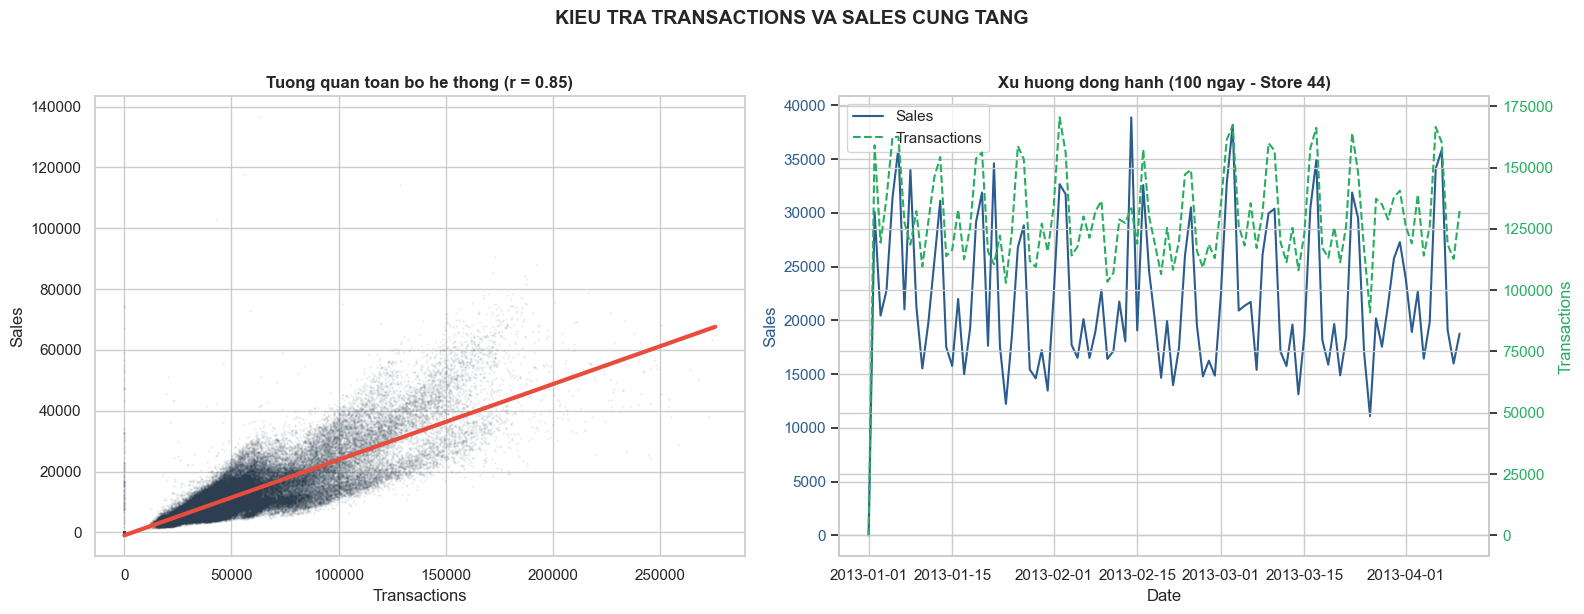

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_grouped = df.groupby(['date', 'store_nbr']).agg({'sales':'sum', 'transactions':'sum'}).reset_index()

sns.regplot(
    data=df_grouped,
    x='transactions',
    y='sales',
    ax=axes[0],
    ci=None,
    scatter_kws={'alpha': 0.05, 'color': '#2c3e50', 's': 1},
    line_kws={'color': '#e74c3c', 'linewidth': 3}
)
corr_val = df_grouped['transactions'].corr(df_grouped['sales'])
axes[0].set_title(f'Tuong quan toan bo he thong (r = {corr_val:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transactions')
axes[0].set_ylabel('Sales')

df_store = df_grouped[df_grouped['store_nbr'] == 44].head(100)

ax2_1 = axes[1]
color_sales = '#2b5c8f'
ax2_1.set_xlabel('Date')
ax2_1.set_ylabel('Sales', color=color_sales)
line1 = ax2_1.plot(df_store['date'], df_store['sales'], color=color_sales, linewidth=1.5, label='Sales')
ax2_1.tick_params(axis='y', labelcolor=color_sales)

ax2_2 = axes[1].twinx()
color_trans = '#27ae60'
ax2_2.set_ylabel('Transactions', color=color_trans)
line2 = ax2_2.plot(df_store['date'], df_store['transactions'], color=color_trans, linewidth=1.5, linestyle='--', label='Transactions')
ax2_2.tick_params(axis='y', labelcolor=color_trans)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_1.legend(lines, labels, loc='upper left')
axes[1].set_title('Xu huong dong hanh (100 ngay - Store 44)', fontsize=12, fontweight='bold')

plt.suptitle('KIEU TRA TRANSACTIONS VA SALES CUNG TANG', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

PHÂN TÍCH OIL CÓ TƯƠNG QUAN VỚI SALES KHÔNG

In [63]:
#Merge oil với train
df = train_data.merge(
    oil_data,
    on = ["date"],
    how = "left"
)
df[["sales", "dcoilwtico"]].corr()

,sales,dcoilwtico
sales,1.000000,-0.078858
dcoilwtico,-0.078858,1.000000


GIÁ XĂNG THEO THỜI GIAN

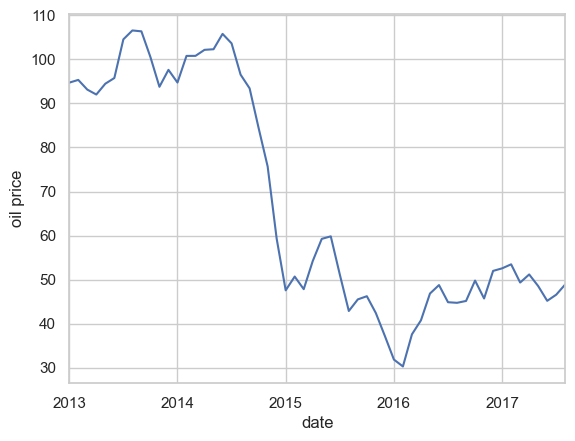

In [64]:
oil_monthly = (
    df.groupby(pd.Grouper(key="date",freq="ME"))["dcoilwtico"]
    .mean()
)

oil_monthly.plot()
plt.ylabel("oil price")
plt.show()

PHÂN TÍCH HOLIDAY 

In [65]:
# 1. Tạo cột logic ngày nghỉ thực tế trên bảng holidays
holidays_events_data['is_real_holiday'] = True
holidays_events_data.loc[(holidays_events_data['type'] == 'Holiday') & (holidays_events_data['transferred'] == True), 'is_real_holiday'] = False
holidays_events_data.loc[holidays_events_data['type'] == 'Work Day', 'is_real_holiday'] = False

# 2. Lọc bớt cột và xóa trùng lặp ngày lễ
holidays_events_data_clean = holidays_events_data[['date', 'type', 'locale', 'is_real_holiday']].drop_duplicates(subset=['date'], keep='first')

# 3. Merge bảng train với bảng lễ đã làm sạch
df_merged = pd.merge(train_data, holidays_events_data_clean, on='date', how='left')

# 4. Điền các giá trị cho ngày thường (ngày không có trong bảng lễ)
df_merged['is_real_holiday'] = df_merged['is_real_holiday'].fillna(False)
df_merged['type'] = df_merged['type'].fillna('Normal Day')
df_merged['locale'] = df_merged['locale'].fillna('None')

# Kiểm tra lại thành quả
print(df_merged.head())


   id       date  store_nbr      family  sales  onpromotion     type  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Holiday   
1   1 2013-01-01          1   BABY CARE    0.0            0  Holiday   
2   2 2013-01-01          1      BEAUTY    0.0            0  Holiday   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Holiday   
4   4 2013-01-01          1       BOOKS    0.0            0  Holiday   

     locale is_real_holiday  
0  National            True  
1  National            True  
2  National            True  
3  National            True  
4  National            True  


C:\Users\TIN\AppData\Local\Temp\ipykernel_10008\368895385.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


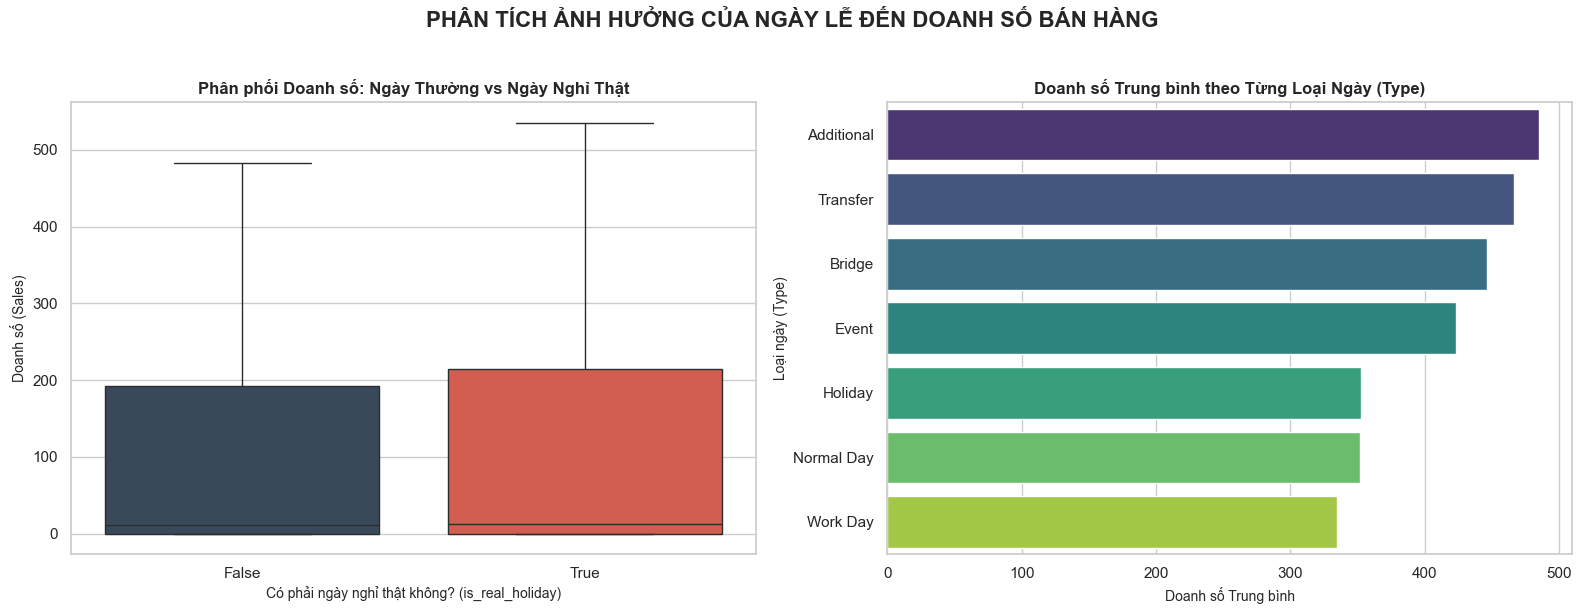

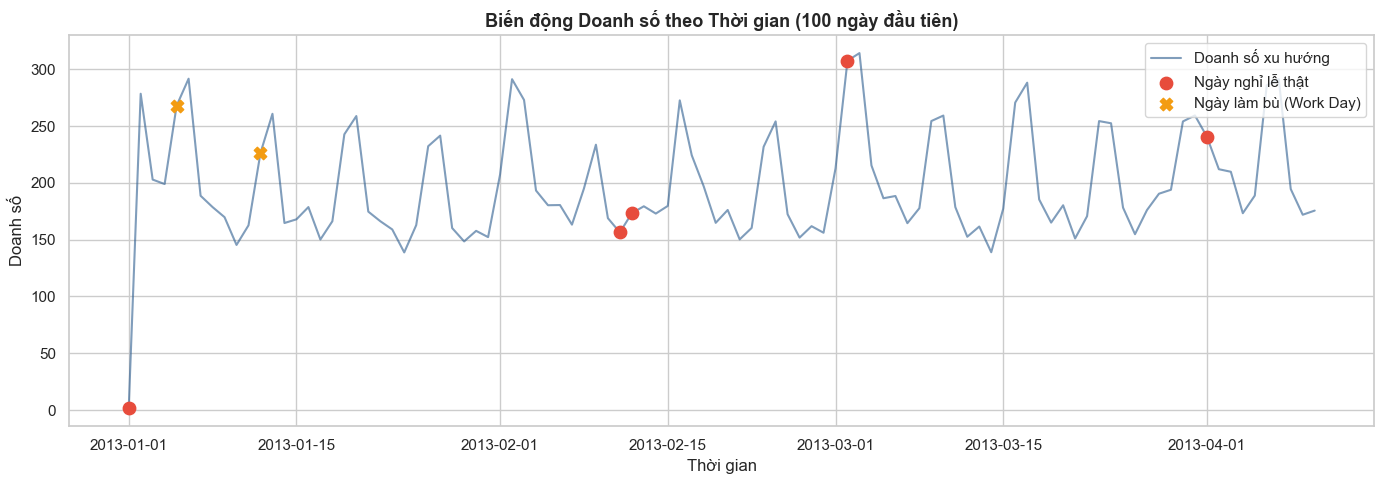

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện chung
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# BIỂU ĐỒ 1: BOXPLOT
# ------------------------------------------------------------------
sns.boxplot(
    data=df_merged, 
    x='is_real_holiday', 
    y='sales', 
    ax=axes[0], 
    palette={'True': '#e74c3c', 'False': '#34495e'},
    showfliers=False
)
axes[0].set_title('Phân phối Doanh số: Ngày Thường vs Ngày Nghỉ Thật', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Có phải ngày nghỉ thật không? (is_real_holiday)', fontsize=10)
axes[0].set_ylabel('Doanh số (Sales)', fontsize=10)


# ------------------------------------------------------------------
# BIỂU ĐỒ 2: BARPLOT 
# ------------------------------------------------------------------
df_type_sales = df_merged.groupby('type', as_index=False)['sales'].mean()
df_type_sales = df_type_sales.sort_values(by='sales', ascending=False)

sns.barplot(
    data=df_type_sales, 
    x='sales', 
    y='type', 
    ax=axes[1],
    hue='type',         
    legend=False,
    palette='viridis'   
)
axes[1].set_title('Doanh số Trung bình theo Từng Loại Ngày (Type)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Doanh số Trung bình', fontsize=10)
axes[1].set_ylabel('Loại ngày (Type)', fontsize=10)

plt.suptitle('PHÂN TÍCH ẢNH HƯỞNG CỦA NGÀY LỄ ĐẾN DOANH SỐ BÁN HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# BIỂU ĐỒ 3: CHUỖI THỜI GIAN (Tự động lấy 100 ngày đầu tiên để tránh bị rỗng)
# ------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Nhóm dữ liệu theo ngày
df_daily = df_merged.groupby('date').agg({'sales': 'mean', 'is_real_holiday': 'first', 'type': 'first'}).reset_index()

df_period = df_daily.head(100) 

# Vẽ đường doanh số
plt.plot(df_period['date'], df_period['sales'], color='#2b5c8f', alpha=0.6, label='Doanh số xu hướng', linewidth=1.5)

# Chấm các điểm ngày nghỉ thật
real_holidays = df_period[df_period['is_real_holiday'] == True]
if not real_holidays.empty:
    plt.scatter(real_holidays['date'], real_holidays['sales'], color='#e74c3c', s=80, label='Ngày nghỉ lễ thật', zorder=3)

# Đánh dấu các ngày Work Day (Làm bù)
work_days = df_period[df_period['type'] == 'Work Day']
if not work_days.empty:
    plt.scatter(work_days['date'], work_days['sales'], color='#f39c12', marker='X', s=80, label='Ngày làm bù (Work Day)', zorder=3)

plt.title('Biến động Doanh số theo Thời gian (100 ngày đầu tiên)', fontsize=13, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Doanh số')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

PHÂN TÍCH Store Type

In [67]:
df = df.merge(
    stores_data,
    on = "store_nbr",
    how = "left"
)

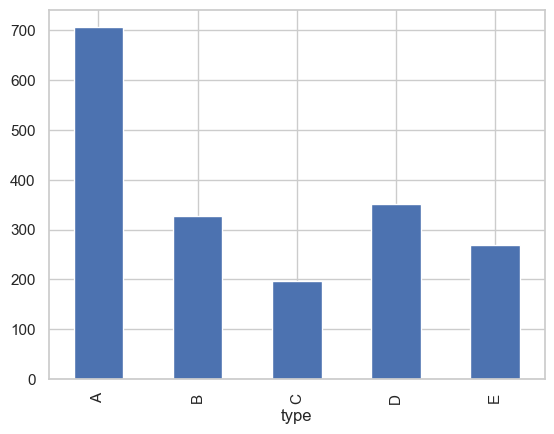

In [68]:
sales_type = (
    df.groupby("type")["sales"]
    .mean()
)
sales_type.plot(kind="bar")
plt.show()

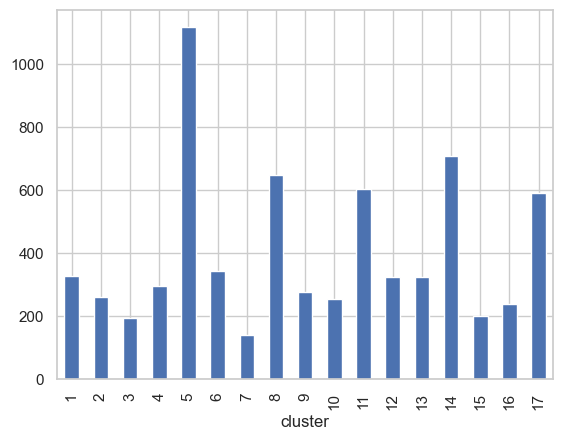

In [69]:
#Phân tích theo cụm 
cluster_sales = (
    df.groupby("cluster")["sales"]
    .mean()
)
cluster_sales.plot(kind="bar")
plt.show()

PHÂN TÍCH DOANH THU THEO NGÀY

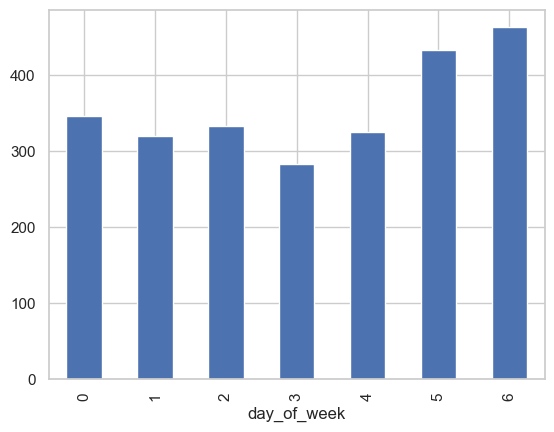

In [70]:
df['day_of_week']  = df['date'].dt.dayofweek

daily_df = df.groupby("day_of_week")["sales"].mean()

daily_df.plot(kind = "bar")
plt.show()

PHÂN TÍCH SALES THEO NGÀY CỦA FAMILY

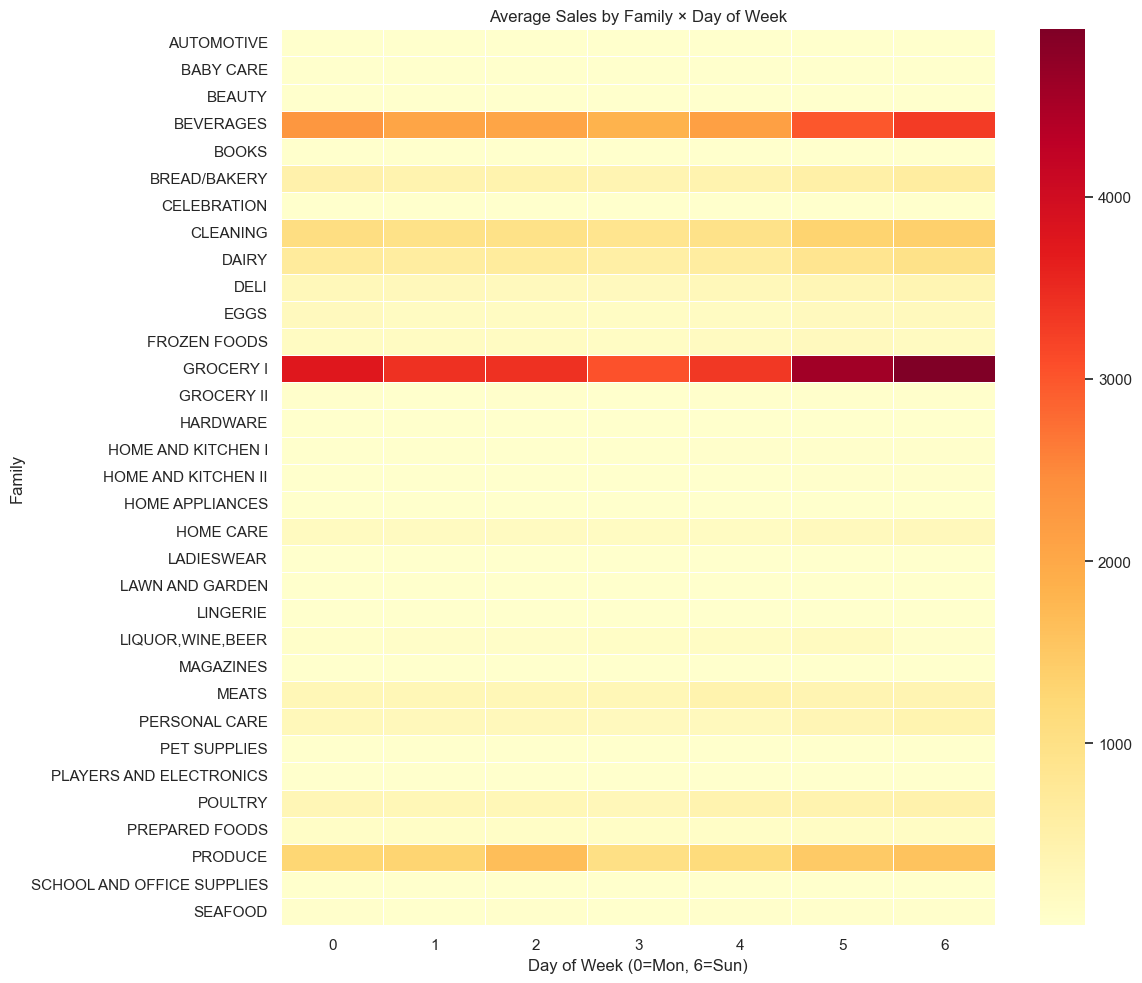

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = (
    df.groupby(['family', 'day_of_week'])['sales']
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5)
plt.title('Average Sales by Family × Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Family')
plt.tight_layout()
plt.show()

TỶ TRỌNG DOANH THU CỦA TỪNG FAMILY TRONG TỔNG DOANH THU

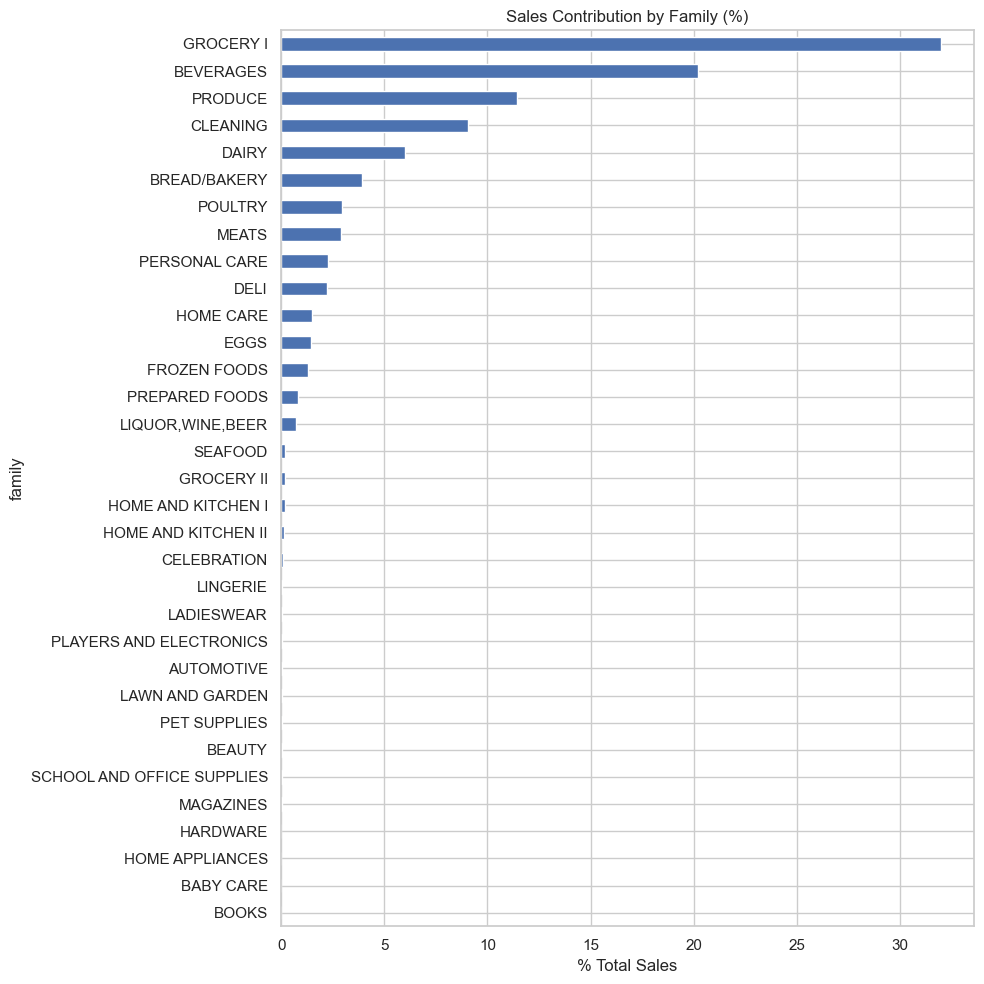

In [72]:
family_pct = (
    df.groupby('family')['sales']
    .sum()
    .sort_values(ascending=True)
)

family_pct_pct = family_pct / family_pct.sum() * 100

plt.figure(figsize=(10, 10))
family_pct_pct.plot(kind='barh')
plt.xlabel('% Total Sales')
plt.title('Sales Contribution by Family (%)')
plt.tight_layout()
plt.show()

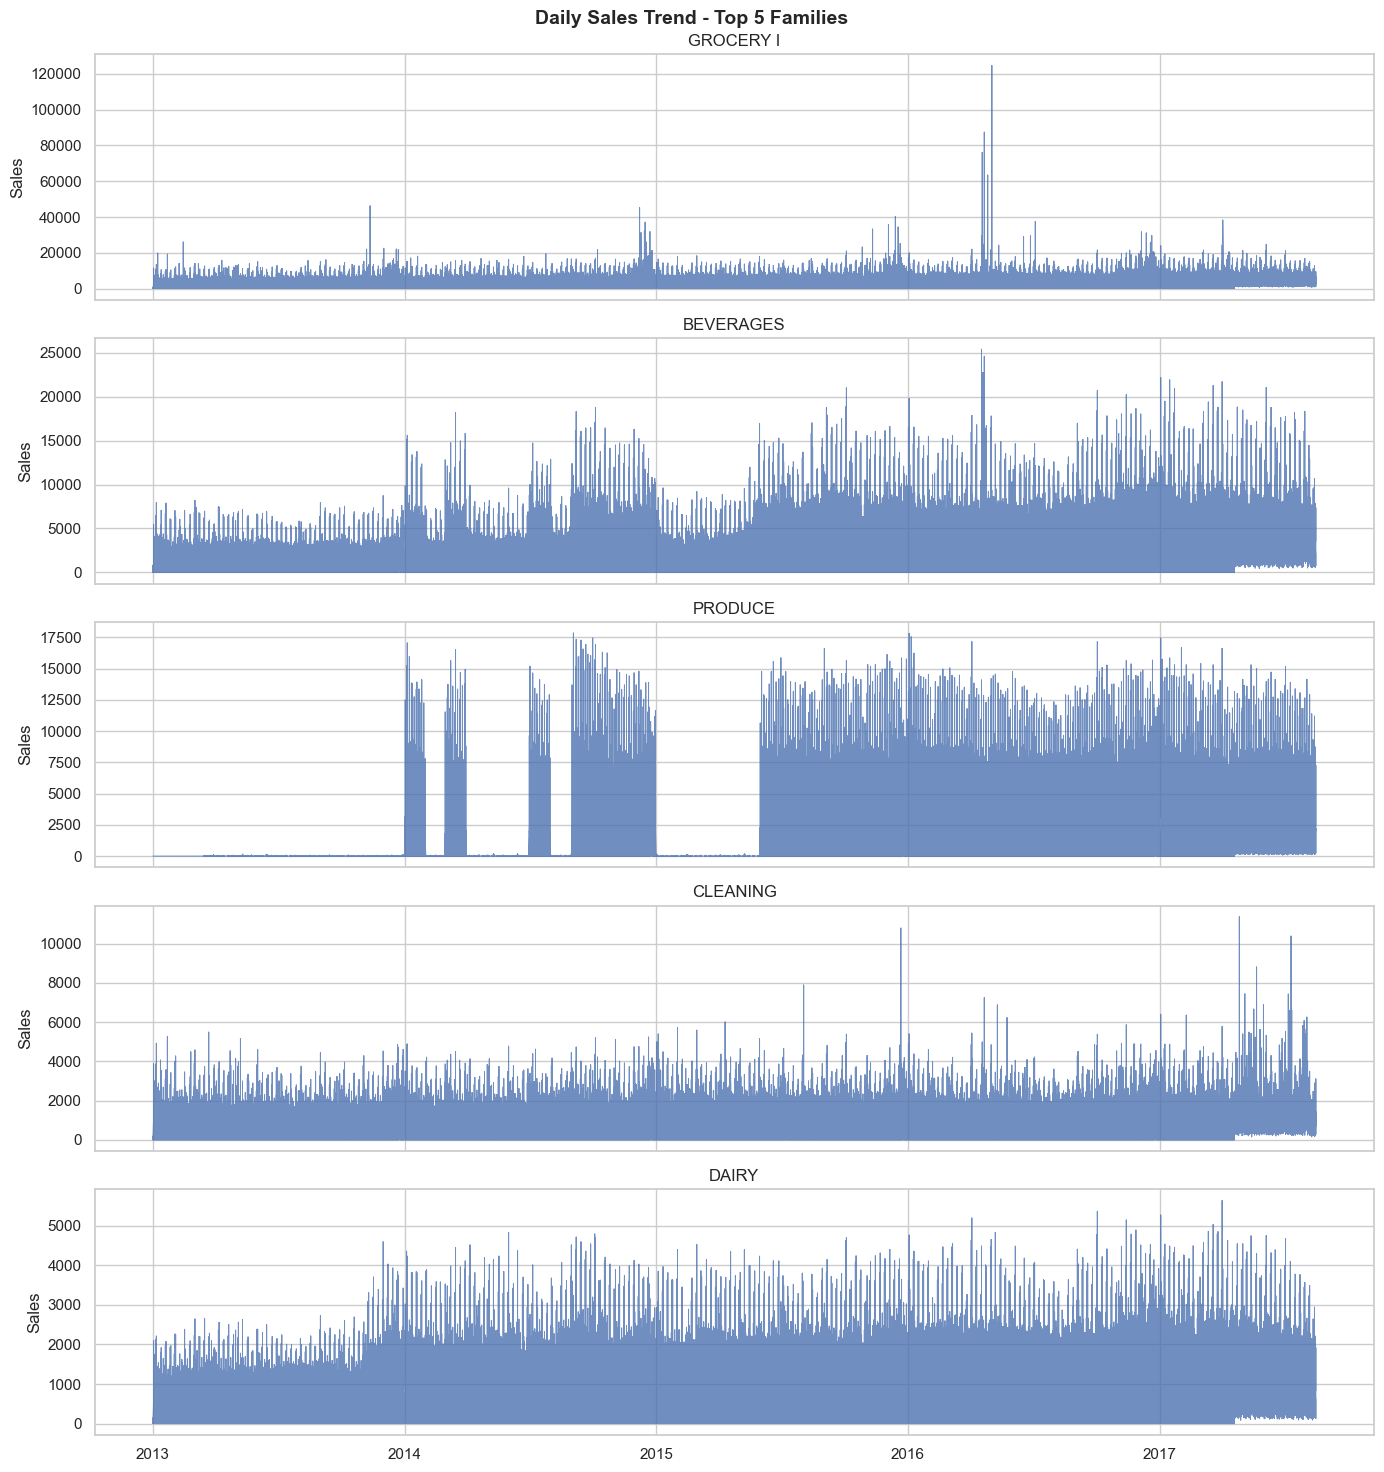

In [73]:
top5 = ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']

fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

for i, fam in enumerate(top5):
    temp = df[df['family'] == fam]
    axes[i].plot(temp['date'], temp['sales'], linewidth=0.7, alpha=0.8)
    axes[i].set_title(fam)
    axes[i].set_ylabel('Sales')

plt.suptitle('Daily Sales Trend - Top 5 Families', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
# Kiểm tra spike GROCERY I
grocery = df[df['family'] == 'GROCERY I']
print(grocery.nlargest(5, 'sales')[['date', 'sales']])

# Kiểm tra gap PRODUCE (những ngày sales = 0)
produce = df[df['family'] == 'PRODUCE']
zero_days = produce[produce['sales'] == 0]
print(f"Số ngày sales = 0: {len(zero_days)}")
print(zero_days[['date', 'sales']].head(10))

              date       sales
2163723 2016-05-02  124717.000
2144154 2016-04-21   87438.516
2139699 2016-04-18   76090.000
2153031 2016-04-26   63434.000
2145045 2016-04-21   53874.000
Số ngày sales = 0: 25785
          date  sales
30  2013-01-01    0.0
63  2013-01-01    0.0
96  2013-01-01    0.0
129 2013-01-01    0.0
162 2013-01-01    0.0
195 2013-01-01    0.0
228 2013-01-01    0.0
261 2013-01-01    0.0
294 2013-01-01    0.0
327 2013-01-01    0.0


In [ ]:
produce = df[df['family'] == 'PRODUCE']

# Phân bố zero theo năm
zero_by_year = (
    produce[produce['sales'] == 0]
    .groupby(produce['date'].dt.year)
    .size()
)
print(zero_by_year)

#top ngày nhiều zero nhất
zero_days = produce[produce['sales'] == 0].copy()
print("\nTop ngày có nhiều zero nhất:")
print(zero_days.groupby('date').size().sort_values(ascending=False).head(10))


zero_days = produce[produce['sales'] == 0].copy()

# Trích xuất subset từ bảng lễ gốc và chủ động đổi tên cột trước để TRÁNH TRÙNG TÊN
holidays_subset = holidays_events_data[['date', 'type', 'description']].rename(
    columns={
        'type': 'holiday_raw_type',           # Đổi tên để không trùng với 'type' cũ của bảng train
        'description': 'holiday_description'  # Đổi tên cho rõ ràng
    }
)

# Tiến hành merge bảng zero với subset ngày lễ đã đổi tên
zero_with_holidays = zero_days.merge(holidays_subset, on='date', how='left')

# Xác định ngày lễ: Nếu cột loại ngày lễ mới không bị NaN thì đó là ngày nghỉ lễ
zero_with_holidays['is_holiday'] = zero_with_holidays['holiday_raw_type'].notna().astype(int)

# In kết quả thống kê tỷ lệ phần trăm
print("📊 Thống kê số lượng ngày Zero:")
print(zero_with_holidays['is_holiday'].value_counts(normalize=True))

# In top các ngày lễ xuất hiện nhiều nhất khi sales bằng 0
print("\nCác ngày lễ xuất hiện nhiều nhất khi sales bằng 0:")
print(
    zero_with_holidays[zero_with_holidays['is_holiday'] == 1]
    .groupby(['date', 'holiday_description'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)


date
2013    13402
2014     6304
2015     5319
2016      599
2017      161
dtype: int64

Top ngày có nhiều zero nhất:
date
2013-02-01    54
2013-03-05    54
2013-01-31    54
2013-01-30    54
2013-01-29    54
2013-01-28    54
2013-01-27    54
2013-01-26    54
2013-01-25    54
2013-01-24    54
dtype: int64
📊 Thống kê số lượng ngày Zero:
is_holiday
0    0.859739
1    0.140261
Name: proportion, dtype: float64

Các ngày lễ xuất hiện nhiều nhất khi sales bằng 0:
date        holiday_description               
2013-01-05  Recupero puente Navidad               54
2013-01-01  Primer dia del ano                    54
2013-01-12  Recupero puente primer dia del ano    54
2013-02-11  Carnaval                              54
2013-02-12  Carnaval                              54
2013-03-02  Fundacion de Manta                    54
2015-01-01  Primer dia del ano                    53
2016-01-01  Primer dia del ano                    53
2017-01-01  Primer dia del ano                    53
2014-01-01  Pri

In [78]:
# Kiểm tra xem 54 stores là tất cả hay một phần
print("Tổng số stores:", df['store_nbr'].nunique() 
      if 'store_nbr' in df.columns else "đã aggregate rồi")

# Nếu daily_df đã aggregate (không còn store_nbr), thì zeros này là 
# toàn bộ hệ thống chưa bán PRODUCE → nên cắt data từ thời điểm 
# PRODUCE bắt đầu ổn định

produce_nonzero = produce[produce['sales'] > 0]
print("Ngày đầu tiên PRODUCE có sales > 0:", produce_nonzero['date'].min())
print("Từ năm nào thì zero < 100 rows/năm:")
print(zero_by_year[zero_by_year < 100])

Tổng số stores: 54
Ngày đầu tiên PRODUCE có sales > 0: 2013-03-16 00:00:00
Từ năm nào thì zero < 100 rows/năm:
Series([], dtype: int64)


TÓM TẮT DỰA TRÊN BIỂU ĐỒ
- Sales phân bổ nhiều ở khoảng 40000 có 1 vài (rất ít) outliner xuất hiện ở 120000.

- Doanh thu theo thời gian là tăng đều qua các năm.

- Doanh thu theo Family, Grocery chiếm khoảng 1/3 doanh số

- Doanh thu theo top 5 family qua thời gian: grocery 1 tăng đều,  beverage tăng đều nhưng ở năm 2015 có gián đoạn, produce giống beverage. Còn Cleaning và Dairy thì doanh thu không dao động quá nhiều qua các năm.

- Doanh thu theo tháng: Tháng 12 cho thấy doanh thu nổi trội hơn các tháng còn lại.

- Giá xăng theo thời gian: Giá xăng từ 2013-2014 dao động nhẹ, từ 2014 - 2016 giảm mạnh, và từ 2016 - 2017 thì tăng nhẹ.

- Doanh thu trong ngay le: Ngay le cao hon ngay thuong mot chut

- Doanh thu theo loại của hàng: của hàng loại A có doanh thu nổi bật hơn hẳn các loại còn lại.

- Doanh thu theo cụm: Các cụm có doanh thu cao hơn phần còn lại là 5, 8, 10, 14, 17. Trong đó cụm 5 là nổi bật nhất, cao rõ rệt so với top cụm cao.

- Doanh thu theo ngày trong tuần: Doanh thu cuối tuần nổi bật hơn so với các doanh thu so với ngày bình thường.

- GROCERY I spike ở tháng 4-5/2016, đây là tuần lễ Semana Santa của Ecuador

- Ta thấy PRODUCE có sales 0 khá nhiều -> Do PRODUCE chưa được bán ở nhiều stores vào đầu năm 2013, tức là stores chưa có category này.

- Kết luận cuối về zeros:
- Giai đoạn: Trước 16/3/2013, nguyên nhân: Chưa có data, xử lý: Cắt bỏ
- Giai đoạn: 2013–2015, nguyên nhân: Nhiều stores chưa bán PRODUCE, xử lý: Cân nhắc cắt hoặc giữ
- Giai đoạn: 2016–2017 , nguyên nhân: Ngày lễ hoặc store lẻ đóng cửa, xử lý: Giữ nguyên, đây là thực tế
           



### CÁC FEATURE CẦN GIỮ VÀ EXPLORE 
##### CẦN GIỮ 
- FAMILY
- MONTH 
- YEAR 
- TYPE
- CLUSTER 
- TRANSACTIONS
##### CẦN EXPLORE
- Lag feature: sales_lag_1, sales_lag_2, sales_lag_3, sales_lag_6, sales_lag_12



In [84]:
import pandas as pd
import numpy as np

# ==================================================
# 1. COPY DATA
# ==================================================

train = train_data.copy()
transactions = transactions_data.copy()
holidays = holidays_events_data.copy()

# ==================================================
# 2. XỬ LÝ HOLIDAY
# ==================================================

holidays['is_real_holiday'] = True

holidays.loc[
    (holidays['type'] == 'Holiday') &
    (holidays['transferred'] == True),
    'is_real_holiday'
] = False

holidays.loc[
    holidays['type'] == 'Work Day',
    'is_real_holiday'
] = False

holidays_clean = (
    holidays[
        ['date', 'type', 'locale', 'is_real_holiday']
    ]
    .drop_duplicates(subset=['date'], keep='first')
)

# ==================================================
# 3. MERGE TRANSACTIONS
# ==================================================

df = pd.merge(
    train,
    transactions,
    on=['date', 'store_nbr'],
    how='left'
)

df['transactions'] = df['transactions'].fillna(0)

# ==================================================
# 4. HOLIDAY FEATURE THEO THÁNG
# ==================================================

holiday_daily = holidays_clean.copy()

holiday_daily['month_date'] = (
    holiday_daily['date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

holiday_dummies = pd.get_dummies(
    holiday_daily['type'],
    prefix='holiday'
)

holiday_daily = pd.concat(
    [holiday_daily, holiday_dummies],
    axis=1
)

agg_dict = {
    'is_real_holiday': 'sum'
}

for col in holiday_dummies.columns:
    agg_dict[col] = 'sum'

holiday_monthly = (
    holiday_daily
    .groupby('month_date')
    .agg(agg_dict)
    .reset_index()
)

holiday_monthly.rename(
    columns={
        'month_date': 'date',
        'is_real_holiday': 'holiday_count'
    },
    inplace=True
)

# ==================================================
# 5. AGGREGATE SALES THEO FAMILY + THÁNG
# ==================================================

monthly_df = (
    df.groupby(
        [
            pd.Grouper(key='date', freq='MS'),
            'family'
        ]
    )
    .agg({
        'sales': 'sum',
        'transactions': 'sum'
    })
    .reset_index()
)

# ==================================================
# 6. MERGE HOLIDAY
# ==================================================

monthly_df = monthly_df.merge(
    holiday_monthly,
    on='date',
    how='left'
)

holiday_cols = [
    col
    for col in monthly_df.columns
    if col.startswith('holiday')
]

monthly_df[holiday_cols] = (
    monthly_df[holiday_cols]
    .fillna(0)
)

# ==================================================
# 7. TIME FEATURES
# ==================================================

monthly_df['year'] = monthly_df['date'].dt.year
monthly_df['month'] = monthly_df['date'].dt.month
monthly_df['quarter'] = monthly_df['date'].dt.quarter

# ==================================================
# 8. SORT
# ==================================================

monthly_df = (
    monthly_df
    .sort_values(
        ['family', 'date']
    )
)

# ==================================================
# 9. LAG FEATURES
# ==================================================

lags = [1, 2, 3, 6, 12]

for lag in lags:

    monthly_df[f'sales_lag_{lag}'] = (
        monthly_df
        .groupby('family')['sales']
        .shift(lag)
    )

# ==================================================
# 10. ROLLING MEAN
# ==================================================

for window in [3, 6, 12]:

    monthly_df[f'rolling_mean_{window}'] = (
        monthly_df
        .groupby('family')['sales']
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window)
             .mean()
        )
    )

# ==================================================
# 11. ROLLING STD
# ==================================================

for window in [3, 6]:

    monthly_df[f'rolling_std_{window}'] = (
        monthly_df
        .groupby('family')['sales']
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window)
             .std()
        )
    )

# ==================================================
# 12. DROP NA
# ==================================================

monthly_df = monthly_df.dropna()

# ==================================================
# 13. CHECK
# ==================================================

print(monthly_df.shape)
print(monthly_df.head())
print(monthly_df.columns.tolist())

# ==================================================
# 14. SAVE
# ==================================================

monthly_df.to_csv(
    'final_dataset.csv',
    index=False
)

print("Saved: final_dataset.csv")

(1452, 24)
          date      family    sales  transactions  holiday_count  \
396 2014-01-01  AUTOMOTIVE   8491.0     2393528.0            1.0   
429 2014-02-01  AUTOMOTIVE   7563.0     2278167.0            0.0   
462 2014-03-01  AUTOMOTIVE  10115.0     2545427.0            3.0   
495 2014-04-01  AUTOMOTIVE   8426.0     2455666.0            5.0   
528 2014-05-01  AUTOMOTIVE   8075.0     2503262.0            5.0   

     holiday_Additional  holiday_Bridge  holiday_Event  holiday_Holiday  \
396                 0.0             0.0            0.0              1.0   
429                 0.0             0.0            0.0              0.0   
462                 0.0             0.0            0.0              3.0   
495                 0.0             0.0            0.0              5.0   
528                 1.0             0.0            1.0              3.0   

     holiday_Transfer  ...  sales_lag_1  sales_lag_2  sales_lag_3  \
396               0.0  ...       8411.0       7166.0       6

In [81]:
print(holiday_monthly.columns)

Index(['date', 'holiday_count', 'holiday_Additional', 'holiday_Bridge',
       'holiday_Event', 'holiday_Holiday', 'holiday_Transfer',
       'holiday_Work Day'],
      dtype='str')
